In [214]:
import matplotlib.pyplot as plt

In [216]:
import seaborn as sns

In [218]:
import pandas as pd

In [220]:
import numpy as np

In [222]:
data=pd.read_csv("Desktop\\year_3\\sem 2\\DS 3003\\assignments\\Final project\\Lung Cancer Dataset.csv")

In [224]:
data.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [226]:
data.duplicated().sum()

0

In [228]:
data.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


In [230]:
# Identify categorical variables (those with only 2-3 unique values)
categorical_vars = [col for col in data.columns if data[col].nunique() <= 3]

# Convert categorical variables to the correct type
data[categorical_vars] = data[categorical_vars].astype("category")

# Display types
print(data.dtypes)

AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
PULMONARY_DISEASE         category
dtype: object


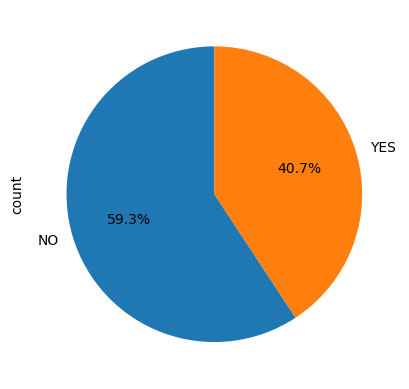

In [231]:
data['PULMONARY_DISEASE'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.show()

In [233]:
import prince

In [235]:
x = data.drop(columns=['PULMONARY_DISEASE'])
y=data['PULMONARY_DISEASE']

In [238]:
from sklearn.model_selection import train_test_split
# Spliting data into train and test
X_train, X_test, y_train_notscaled, y_test_notscaled = train_test_split(x, y, train_size=.8, random_state=42)
# Checking if the splits are correct
print(f"Train size: {round(len(X_train) / len(x) * 100)}% \n\
Test size: {round(len(X_test) / len(x) * 100)}%")

Train size: 80% 
Test size: 20%


In [239]:
X_train.dtypes

AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
dtype: object

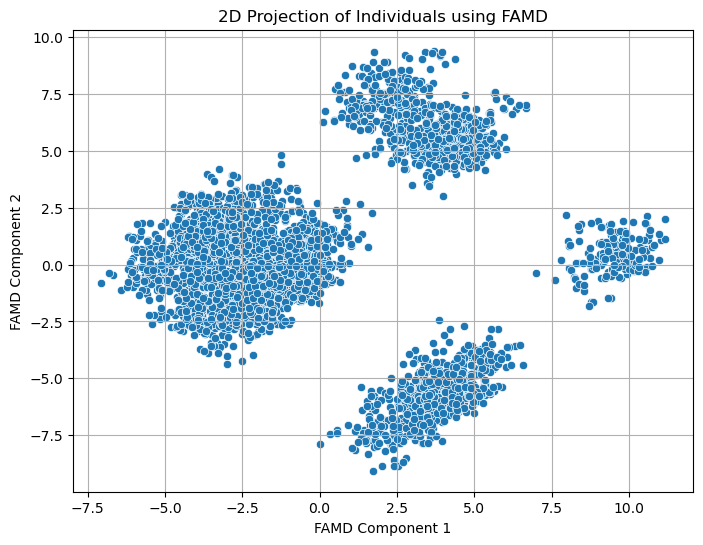

In [240]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince

#  Applying FAMD on the dataset
famd = prince.FAMD(n_components=2, random_state=42)
famd = famd.fit(X_train)
X_famd= famd.transform(X_train)

#  Scatter Plot of FAMD-reduced Data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_famd[0], y=X_famd[1])
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.title("2D Projection of Individuals using FAMD")
plt.grid(True)
plt.show()


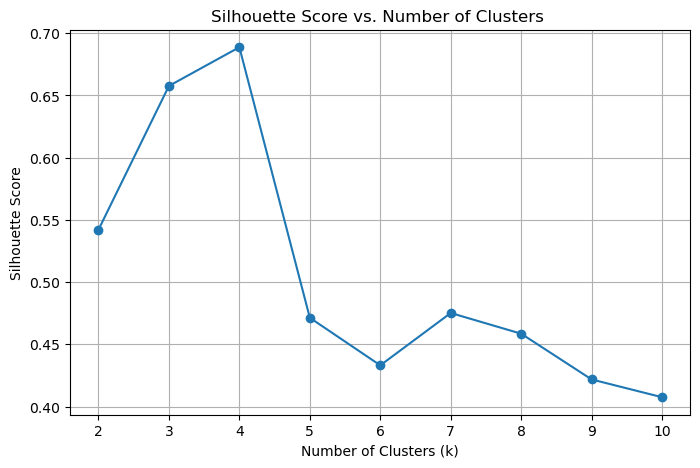

In [244]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    score = silhouette_score(X_famd, labels)
    silhouette_scores.append(score)

#  Plot of Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters ")
plt.xticks(K_range)
plt.grid(True)
plt.show()

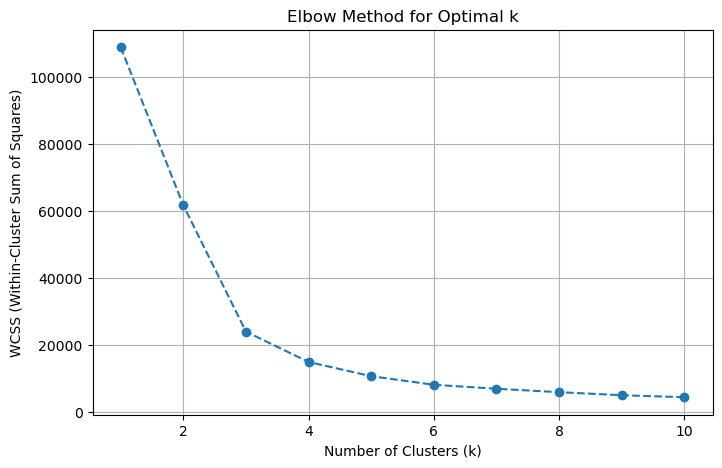

In [245]:

range_n_clusters = np.arange(1, 11)  
wcss = []  

# Computong WCSS for each k
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_famd)
    wcss.append(kmeans.inertia_)  

# Plot for the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

component          0         1
4227       10.574126  2.150854
4676       -1.467227 -0.158796
800         3.458001 -4.226259
3671       -2.371635  1.158752
4193       -1.977794 -2.244654
...              ...       ...
4426       -1.551352 -2.085693
466         5.390410  6.317203
3092       -3.053413 -0.373476
3772       -3.948207  0.014965
860        -1.954540 -2.009557

[4000 rows x 2 columns]


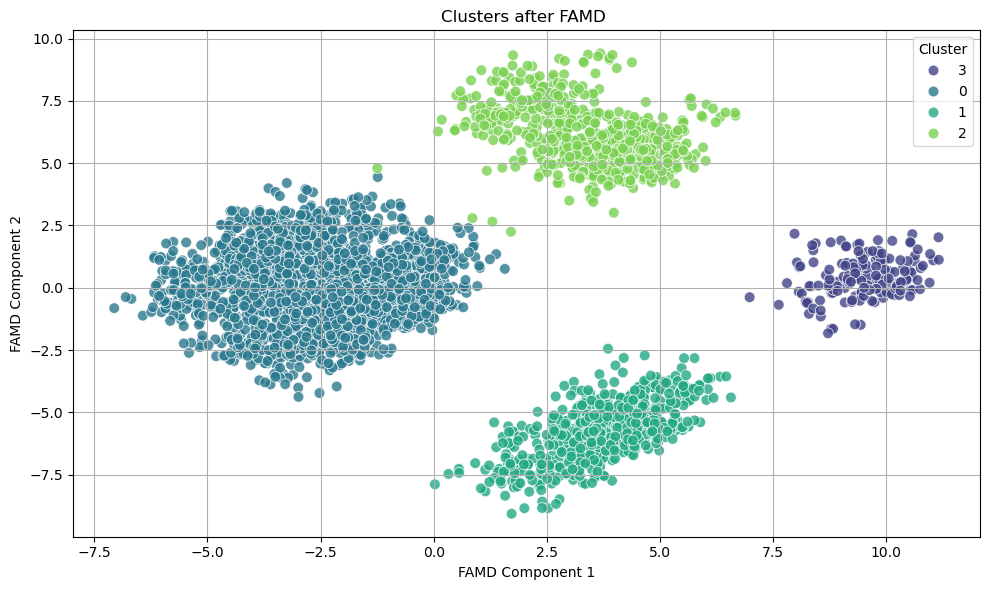

In [246]:
plot_df =  pd.DataFrame(X_famd)
print(plot_df)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(plot_df)

plot_df['Cluster'] = clusters.astype(str)  

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x=0, y=1, hue='Cluster', palette='viridis', s=60, alpha=0.8)

plt.title("Clusters after FAMD ")
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [247]:
famd = prince.FAMD(n_components=2, random_state=42)
famd_test = famd.fit(X_test)
X_test_famd = famd_test.transform(X_test)


X_famd.columns = X_famd.columns.astype(str)
X_test_famd.columns=X_test_famd.columns.astype(str)

kmeans = KMeans(n_clusters=4, random_state=42)
X_train['Cluster'] = kmeans.fit_predict(X_famd)
X_test['Cluster'] = kmeans.predict(X_test_famd)

y_train_clustered = pd.concat([y_train_notscaled, X_train['Cluster']], axis=1)
y_test_clustered = pd.concat([y_test_notscaled, X_test['Cluster']], axis=1)



In [252]:
print(X_train["Cluster"].value_counts())

Cluster
0    2520
1     668
2     647
3     165
Name: count, dtype: int64


In [253]:
print(y_train_clustered)

     PULMONARY_DISEASE  Cluster
4227               YES        3
4676               YES        0
800                YES        1
3671               YES        0
4193                NO        0
...                ...      ...
4426                NO        0
466                 NO        2
3092                NO        0
3772                NO        0
860                 NO        0

[4000 rows x 2 columns]


In [257]:
print(X_famd)

component          0         1
4227       10.574126  2.150854
4676       -1.467227 -0.158796
800         3.458001 -4.226259
3671       -2.371635  1.158752
4193       -1.977794 -2.244654
...              ...       ...
4426       -1.551352 -2.085693
466         5.390410  6.317203
3092       -3.053413 -0.373476
3772       -3.948207  0.014965
860        -1.954540 -2.009557

[4000 rows x 2 columns]


In [259]:
print(X_train)

      AGE GENDER SMOKING FINGER_DISCOLORATION MENTAL_STRESS  \
4227   63      1       1                    1             1   
4676   70      1       1                    1             1   
800    60      0       1                    1             1   
3671   40      1       1                    1             0   
4193   40      0       0                    0             0   
...   ...    ...     ...                  ...           ...   
4426   43      1       0                    1             0   
466    52      1       1                    0             1   
3092   75      1       0                    0             0   
3772   43      1       0                    1             0   
860    47      1       1                    1             0   

     EXPOSURE_TO_POLLUTION LONG_TERM_ILLNESS  ENERGY_LEVEL IMMUNE_WEAKNESS  \
4227                     0                 0     49.129678               1   
4676                     1                 0     62.047864               0   
800      

In [261]:
print(X_test)

      AGE GENDER SMOKING FINGER_DISCOLORATION MENTAL_STRESS  \
1501   80      1       1                    0             1   
2586   74      0       1                    1             0   
2653   42      1       1                    0             1   
1055   76      1       0                    1             0   
705    68      0       1                    0             1   
...   ...    ...     ...                  ...           ...   
4711   40      0       1                    1             0   
2313   83      0       1                    0             1   
3214   80      1       0                    1             1   
2732   71      0       1                    0             1   
1926   42      1       1                    1             1   

     EXPOSURE_TO_POLLUTION LONG_TERM_ILLNESS  ENERGY_LEVEL IMMUNE_WEAKNESS  \
1501                     1                 1     42.962294               0   
2586                     0                 0     48.962895               1   
2653     

In [263]:
print(y_test_clustered)

     PULMONARY_DISEASE  Cluster
1501                NO        0
2586                NO        1
2653                NO        1
1055                NO        0
705                 NO        1
...                ...      ...
4711                NO        0
2313                NO        0
3214                NO        2
2732                NO        0
1926               YES        3

[1000 rows x 2 columns]


In [265]:
X_train.dtypes


AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
Cluster                      int32
dtype: object

In [267]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate=ing columns
X_train_features = X_train.drop(columns='Cluster')

# Identifying column types
numeric_features = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
categorical_features = [col for col in X_train_features.columns if col not in numeric_features]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [269]:
print(numeric_features)

['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']


In [271]:
len(X_train)

4000

In [273]:
# Filter Cluster 0 for training set
X_cluster0 = X_train[X_train['Cluster'] == 0].drop(columns='Cluster')
y_cluster0 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 0].index]

# Filter Cluster 0 for test set
X_test_c0 = X_test[X_test['Cluster'] == 0].drop(columns='Cluster')
y_test_c0 = y_test_notscaled.loc[X_test_c0.index]

In [275]:
len(X_cluster0)

2520

In [277]:
print(y_test_c0)

1501     NO
1055     NO
106      NO
2468    YES
2413     NO
       ... 
2307     NO
4424    YES
4711     NO
2313     NO
2732     NO
Name: PULMONARY_DISEASE, Length: 611, dtype: category
Categories (2, object): ['NO', 'YES']


In [279]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

lr_pipeline.fit(X_cluster0, y_cluster0)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', LogisticRegression())])

In [281]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_cluster0, y_cluster0)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [283]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

svm_pipeline.fit(X_cluster0, y_cluster0)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', SVC())])

In [284]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_cluster0, y_cluster0)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [286]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,precision_score,recall_score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # If predictions are probabilities, converting them to binary classes ('YES'/'NO')
    if y_pred.ndim == 2:  
        y_pred = (y_pred[:, 1] > 0.5).astype(str)  
    
    if isinstance(y_test, pd.DataFrame):  
        y_test = y_test.iloc[:, 0] 
    
    if y_test.dtype == 'int64':
        y_test = y_test.astype(str)  
    
    # Computing evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='YES')
    recall = recall_score(y_test, y_pred, pos_label='YES')
    f1 = f1_score(y_test, y_pred, pos_label='YES')
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")



    



# Evaluating different models
print("Logistic Regression test set")
evaluate_model(lr_pipeline, X_test_c0, y_test_c0)

print("Decision Tree test set")
evaluate_model(dt_pipeline, X_test_c0, y_test_c0)

print("SVM test set")
evaluate_model(svm_pipeline, X_test_c0, y_test_c0)

print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c0, y_test_c0)



Logistic Regression test set
Accuracy: 0.9149
Precision: 0.8454
Recall: 0.8974
F1 Score: 0.8706
Confusion Matrix:
[[384  32]
 [ 20 175]]

Decision Tree test set
Accuracy: 0.8412
Precision: 0.7333
Recall: 0.7897
F1 Score: 0.7605
Confusion Matrix:
[[360  56]
 [ 41 154]]

SVM test set
Accuracy: 0.9198
Precision: 0.8614
Recall: 0.8923
F1 Score: 0.8766
Confusion Matrix:
[[388  28]
 [ 21 174]]

Random Forest test set
Accuracy: 0.9214
Precision: 0.8848
Recall: 0.8667
F1 Score: 0.8756
Confusion Matrix:
[[394  22]
 [ 26 169]]



In [287]:
# Evaluating different models
print("Logistic Regression training set")
evaluate_model(lr_pipeline, X_cluster0, y_cluster0)

print("Decision Tree training set")
evaluate_model(dt_pipeline, X_cluster0, y_cluster0)

print("SVM training set")
evaluate_model(svm_pipeline, X_cluster0, y_cluster0)

print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster0, y_cluster0)

Logistic Regression training set
Accuracy: 0.9048
Precision: 0.8326
Recall: 0.8231
F1 Score: 0.8278
Confusion Matrix:
[[1703  116]
 [ 124  577]]

Decision Tree training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[1819    0]
 [   0  701]]

SVM training set
Accuracy: 0.9159
Precision: 0.8699
Recall: 0.8203
F1 Score: 0.8443
Confusion Matrix:
[[1733   86]
 [ 126  575]]

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[1819    0]
 [   0  701]]



In [291]:
#XGBoost performance for all clusters are given at the end of the code

In [293]:
# we selected random forest as the best model for cluster 0

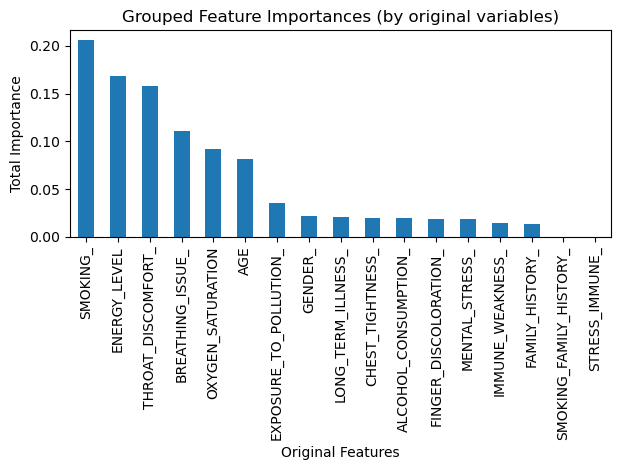

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Extracting feature importances from  Random Forest model
importances = rf_pipeline.named_steps['classifier'].feature_importances_

#Retrieving the feature names after preprocessing 
preprocessed_columns = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

grouped_importances = {}

#Grouping the importances by the original feature name
for col, importance in zip(preprocessed_columns, importances):
    base = re.match(r"([a-zA-Z_]+)", col)  
    if base:
        base = base.group(1)  
        grouped_importances[base] = grouped_importances.get(base, 0) + importance

grouped_importance_df = pd.Series(grouped_importances).sort_values(ascending=False)
grouped_importance_df.index = [re.sub(r"^(cat__|float64_|int64_|num__)", "", col) for col in grouped_importance_df.index]

grouped_importance_df.plot.bar()
plt.title("Grouped Feature Importances (by original variables)")
plt.ylabel("Total Importance")
plt.xlabel("Original Features")
plt.tight_layout()
plt.savefig("feature importance for cluster0 by random forest model.png", dpi=300, bbox_inches='tight')
plt.show()


Optimal number of features: 16
Ranking of features: [ 1  1  1  5  1  1  1  7  1  1 10  1  1  1  6 12  4  1  1  9  2  1  1  8
  1 11  3 13 14]
Selected Original Features (after grouping dummies):
• AGE
• BREATHING
• CHEST
• EXPOSURE
• GENDER
• IMMUNE
• LONG
• MENTAL
• OXYGEN
• SMOKING
• THROAT


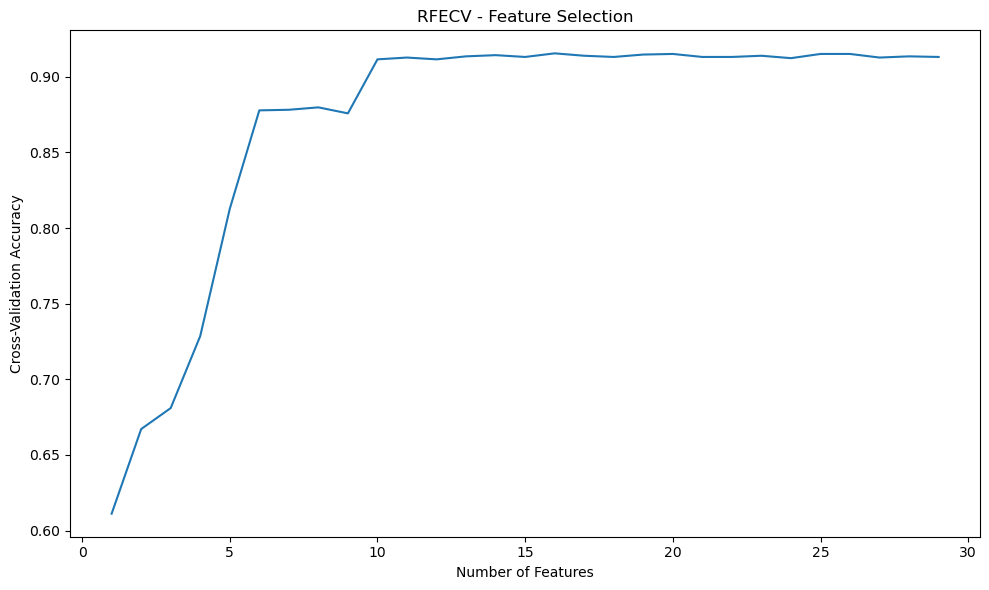

In [297]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rf_classifier = RandomForestClassifier(random_state=42)

rfecv = RFECV(estimator=rf_classifier, 
              step=1,  
              cv=StratifiedKFold(5),  
              scoring='accuracy',  
              n_jobs=-1)  

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('feature_selection', rfecv),  
    ('classifier', rf_classifier)  
])

rf_pipeline.fit(X_cluster0, y_cluster0)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Ranking of features: {rfecv.ranking_}")

import matplotlib.pyplot as plt

all_feature_names = x.columns.tolist()
selected_features_full = [name for name, selected in zip(all_feature_names, rfecv.support_) if selected]

selected_base_features = set()
for feat in selected_features_full:
    match = re.match(r'^([a-zA-Z0-9]+)', feat)
    if match:
        selected_base_features.add(match.group(1))

print("Selected Original Features (after grouping dummies):")
for feat in sorted(selected_base_features):
    print(f"• {feat}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'])
plt.title('RFECV - Feature Selection')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.tight_layout()
plt.show()


In [299]:
# Filter Cluster 1 for training set
X_cluster1 = X_train[X_train['Cluster'] == 1].drop(columns='Cluster')
y_cluster1 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 1].index]

# Filter Cluster 1 for test set
X_test_c1 = X_test[X_test['Cluster'] == 1].drop(columns='Cluster')
y_test_c1 = y_test_notscaled.loc[X_test_c1.index]

In [301]:
len(X_cluster1)

668

In [303]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [305]:
lr_pipeline.fit(X_cluster1, y_cluster1)
dt_pipeline.fit(X_cluster1, y_cluster1)
svm_pipeline.fit(X_cluster1, y_cluster1)
rf_pipeline.fit(X_cluster1, y_cluster1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [307]:
# evaluateing for Cluster 1
print("Logistic Regression test set")
evaluate_model(lr_pipeline, X_test_c1, y_test_c1)

print("Decision Tree test set")
evaluate_model(dt_pipeline, X_test_c1, y_test_c1)

print("SVM test set")
evaluate_model(svm_pipeline, X_test_c1, y_test_c1)

print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c1, y_test_c1)

    



Logistic Regression test set
Accuracy: 0.9006
Precision: 0.8957
Recall: 0.9537
F1 Score: 0.9238
Confusion Matrix:
[[ 51  12]
 [  5 103]]

Decision Tree test set
Accuracy: 0.7251
Precision: 0.7699
Recall: 0.8056
F1 Score: 0.7873
Confusion Matrix:
[[37 26]
 [21 87]]

SVM test set
Accuracy: 0.8596
Precision: 0.8889
Recall: 0.8889
F1 Score: 0.8889
Confusion Matrix:
[[51 12]
 [12 96]]

Random Forest test set
Accuracy: 0.8830
Precision: 0.8929
Recall: 0.9259
F1 Score: 0.9091
Confusion Matrix:
[[ 51  12]
 [  8 100]]



In [309]:
#Evaluating for cluster 1
print("Logistic Regression training set")
evaluate_model(lr_pipeline, X_cluster1, y_cluster1)

print("Decision Tree training set")
evaluate_model(dt_pipeline, X_cluster1, y_cluster1)

print("SVM training set")
evaluate_model(svm_pipeline, X_cluster1, y_cluster1)

print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster1, y_cluster1)

Logistic Regression training set
Accuracy: 0.8922
Precision: 0.8879
Recall: 0.9035
F1 Score: 0.8957
Confusion Matrix:
[[287  39]
 [ 33 309]]

Decision Tree training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[326   0]
 [  0 342]]

SVM training set
Accuracy: 0.9192
Precision: 0.9091
Recall: 0.9357
F1 Score: 0.9222
Confusion Matrix:
[[294  32]
 [ 22 320]]

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[326   0]
 [  0 342]]



In [ ]:
# we selected logistic regression as the best model for cluster 1

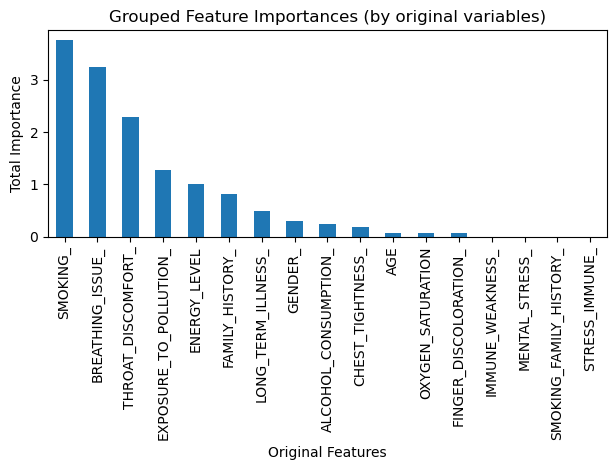

In [311]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

#Extracting the coefficients from Logistic Regression model
coefficients = lr_pipeline.named_steps['classifier'].coef_.flatten()  

#Retrieving the feature names after preprocessing 
preprocessed_columns = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

grouped_importances = {}

for col, coefficient in zip(preprocessed_columns, coefficients):
    base = re.match(r"([a-zA-Z_]+)", col) 
    if base:
        base = base.group(1)  
        grouped_importances[base] = grouped_importances.get(base, 0) + abs(coefficient)  

grouped_importance_df = pd.Series(grouped_importances).sort_values(ascending=False)
grouped_importance_df.index = [re.sub(r"^(cat__|float64_|int64_|num__)", "", col) for col in grouped_importance_df.index]

grouped_importance_df.plot.bar()
plt.title("Grouped Feature Importances (by original variables)")
plt.ylabel("Total Importance")
plt.xlabel("Original Features")
plt.tight_layout()
plt.show()


Optimal number of features: 9
Ranking of features: [12  1 13  9  6  1  1 15 14 17  2  1  3  7 16  1  1 10  5  1  1 11  8  1
  4 18 19]
 Selected Original Features (after grouping dummies):
• EXPOSURE
• GENDER
• LONG
• SMOKING
• STRESS
• THROAT


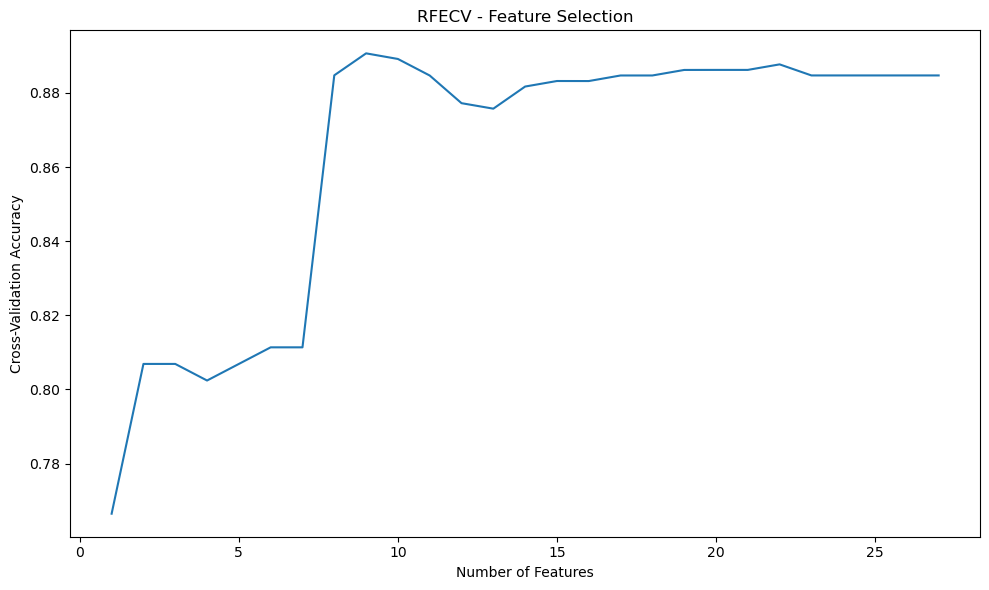

In [313]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_classifier = LogisticRegression(random_state=42, max_iter=1000)

rfecv = RFECV(estimator=lr_classifier, 
              step=1,  
              cv=StratifiedKFold(5),  
              scoring='accuracy',  
              n_jobs=-1) 

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('feature_selection', rfecv),  
    ('classifier', lr_classifier)  
])

lr_pipeline.fit(X_cluster1, y_cluster1)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Ranking of features: {rfecv.ranking_}")

import matplotlib.pyplot as plt
all_feature_names = x.columns.tolist()
selected_features_full = [name for name, selected in zip(all_feature_names, rfecv.support_) if selected]

selected_base_features = set()
for feat in selected_features_full:
    match = re.match(r'^([a-zA-Z0-9]+)', feat)
    if match:
        selected_base_features.add(match.group(1))
print(" Selected Original Features (after grouping dummies):")
for feat in sorted(selected_base_features):
    print(f"• {feat}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'])
plt.title('RFECV - Feature Selection')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.tight_layout()
plt.show()


In [ ]:
#model suggested by RFE doesn't perform well for test set since we decided to look at he feature importance plot select the features that improves both training accuracy and test accuracy

In [315]:
# Filter Cluster 2 for training set
X_cluster2 = X_train[X_train['Cluster'] == 2].drop(columns='Cluster')
y_cluster2 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 2].index]

# Filter Cluster 2 for test set
X_test_c2 = X_test[X_test['Cluster'] == 2].drop(columns='Cluster')
y_test_c2 = y_test_notscaled.loc[X_test_c2.index]

In [317]:
len(X_cluster2)

647

In [319]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [321]:
lr_pipeline.fit(X_cluster2, y_cluster2)
dt_pipeline.fit(X_cluster2, y_cluster2)
svm_pipeline.fit(X_cluster2, y_cluster2)
rf_pipeline.fit(X_cluster2, y_cluster2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE', 'ENERGY_LEVEL',
                                                   'OXYGEN_SATURATION']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GENDER', 'SMOKING',
                                                   'FINGER_DISCOLORATION',
                                                   'MENTAL_STRESS',
                                                   'EXPOSURE_TO_POLLUTION',
                                                   'LONG_TERM_ILLNESS',
                                                   'IMMUNE_WEAKNESS',
                                                   'BREATHING_ISSUE',
                                                   'ALCOHOL_CONSUMPTION',
                                                   'THROAT_DISCOMFORT',
                                                   'CHEST_TIGHTNESS',
                                                   'FAMILY_HISTORY',
                                                   'SMOKING_FAMILY_HISTORY',
                                                   'STRESS_IMMUNE'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [322]:
#evaluating for Cluster 2
print("Logistic Regression test set")
evaluate_model(lr_pipeline, X_test_c2, y_test_c2)

print("Decision Tree test set")
evaluate_model(dt_pipeline, X_test_c2, y_test_c2)

print("SVM test set")
evaluate_model(svm_pipeline, X_test_c2, y_test_c2)

print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c2, y_test_c2)

Logistic Regression test set
Accuracy: 0.7310
Precision: 0.7033
Recall: 0.7711
F1 Score: 0.7356
Confusion Matrix:
[[61 27]
 [19 64]]

Decision Tree test set
Accuracy: 0.7661
Precision: 0.8116
Recall: 0.6747
F1 Score: 0.7368
Confusion Matrix:
[[75 13]
 [27 56]]

SVM test set
Accuracy: 0.6608
Precision: 0.6087
Recall: 0.8434
F1 Score: 0.7071
Confusion Matrix:
[[43 45]
 [13 70]]

Random Forest test set
Accuracy: 0.7719
Precision: 0.8333
Recall: 0.6627
F1 Score: 0.7383
Confusion Matrix:
[[77 11]
 [28 55]]



In [324]:
# Evaluating for cluster 2
print("Logistic Regression training set")
evaluate_model(lr_pipeline, X_cluster2, y_cluster2)

print("Decision Tree training set")
evaluate_model(dt_pipeline, X_cluster2, y_cluster2)

print("SVM training set")
evaluate_model(svm_pipeline, X_cluster2, y_cluster2)

print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster2, y_cluster2)

Logistic Regression training set
Accuracy: 0.9134
Precision: 0.9318
Recall: 0.9362
F1 Score: 0.9340
Confusion Matrix:
[[195  29]
 [ 27 396]]

Decision Tree training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[224   0]
 [  0 423]]

SVM training set
Accuracy: 0.9289
Precision: 0.9435
Recall: 0.9480
F1 Score: 0.9458
Confusion Matrix:
[[200  24]
 [ 22 401]]

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[224   0]
 [  0 423]]



In [ ]:
# we selected random forest as the best model for cluster 2

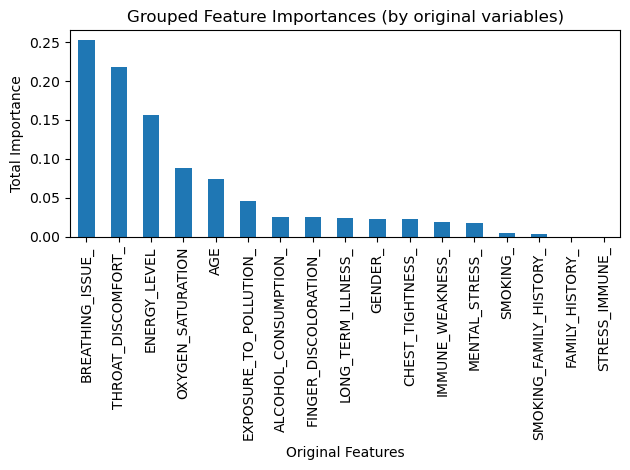

In [326]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Extracting the feature importances from Random Forest model
importances = rf_pipeline.named_steps['classifier'].feature_importances_

#Retrieving the feature names after preprocessing 
preprocessed_columns = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

grouped_importances = {}

for col, importance in zip(preprocessed_columns, importances):
    base = re.match(r"([a-zA-Z_]+)", col)  
    if base:
        base = base.group(1)  
        grouped_importances[base] = grouped_importances.get(base, 0) + importance

grouped_importance_df = pd.Series(grouped_importances).sort_values(ascending=False)
grouped_importance_df.index = [re.sub(r"^(cat__|float64_|int64_|num__)", "", col) for col in grouped_importance_df.index]

grouped_importance_df.plot.bar()
plt.title("Grouped Feature Importances (by original variables)")
plt.ylabel("Total Importance")
plt.xlabel("Original Features")
plt.tight_layout()
plt.show()

Optimal number of features: 13
Ranking of features: [ 1  1  1 10  2 13 15  8  1  9  4  1  1  6  1 11  3  1  1  5  1  1  1  1
  7 16 14 12 17]
 Selected Original Features (after grouping dummies):
• AGE
• FAMILY
• GENDER
• IMMUNE
• OXYGEN
• SMOKING
• THROAT


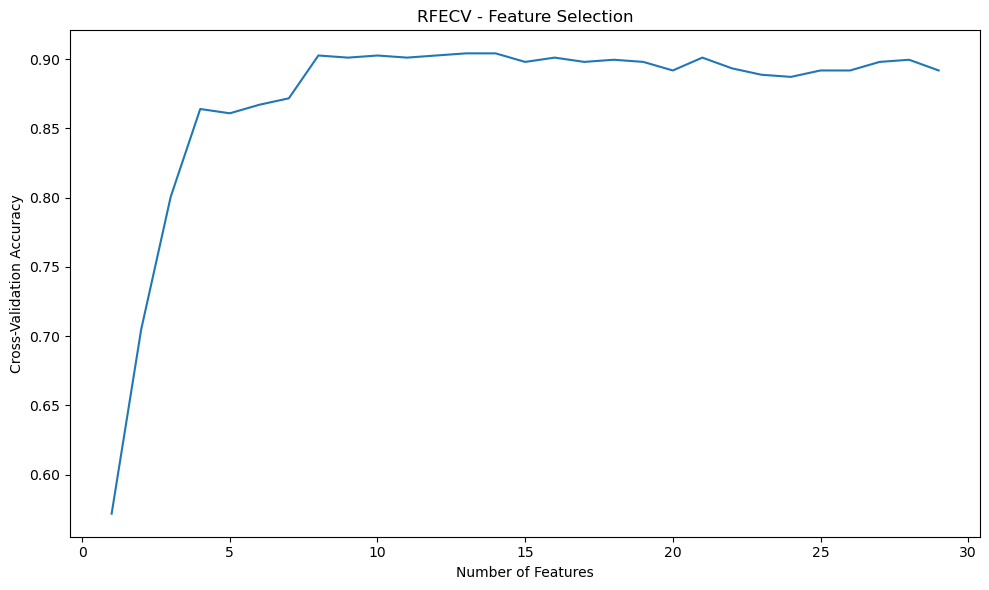

In [328]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rf_classifier = RandomForestClassifier(random_state=42)

rfecv = RFECV(estimator=rf_classifier, 
              step=1,  
              cv=StratifiedKFold(5),  
              scoring='accuracy',  
              n_jobs=-1)  

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('feature_selection', rfecv),  
    ('classifier', rf_classifier) 
])

rf_pipeline.fit(X_cluster2, y_cluster2)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Ranking of features: {rfecv.ranking_}")

import matplotlib.pyplot as plt

all_feature_names = x.columns.tolist()
selected_features_full = [name for name, selected in zip(all_feature_names, rfecv.support_) if selected]

selected_base_features = set()
for feat in selected_features_full:
    match = re.match(r'^([a-zA-Z0-9]+)', feat)
    if match:
        selected_base_features.add(match.group(1))

print(" Selected Original Features (after grouping dummies):")
for feat in sorted(selected_base_features):
    print(f"• {feat}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'])
plt.title('RFECV - Feature Selection')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.tight_layout()
plt.show()


In [ ]:
#model suggested by RFE doesn't perform well for test set since we decided to look at he feature importance plot select the features that improves both training accuracy and test accuracy

In [329]:
# Filter Cluster 3 for training set
X_cluster3 = X_train[X_train['Cluster'] == 3].drop(columns='Cluster')
y_cluster3 = y_train_notscaled.loc[X_train[X_train['Cluster'] == 3].index]
print(len(X_cluster3))
# Filter Cluster 3 for test set
X_test_c3 = X_test[X_test['Cluster'] == 3].drop(columns='Cluster')
y_test_c3 = y_test_notscaled.loc[X_test_c3.index]

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

lr_pipeline.fit(X_cluster3, y_cluster3)
dt_pipeline.fit(X_cluster3, y_cluster3)
svm_pipeline.fit(X_cluster3, y_cluster3)
rf_pipeline.fit(X_cluster3, y_cluster3)

#evaluating for Cluster 3
print("Logistic Regression test set")
evaluate_model(lr_pipeline, X_test_c3, y_test_c3)

print("Decision Tree test set")
evaluate_model(dt_pipeline, X_test_c3, y_test_c3)

print("SVM test set")
evaluate_model(svm_pipeline, X_test_c3, y_test_c3)

print("Random Forest test set")
evaluate_model(rf_pipeline, X_test_c3, y_test_c3)

#evaluating for cluster 3
print("Logistic Regression training set")
evaluate_model(lr_pipeline, X_cluster3, y_cluster3)

print("Decision Tree training set")
evaluate_model(dt_pipeline, X_cluster3, y_cluster3)

print("SVM training set")
evaluate_model(svm_pipeline, X_cluster3, y_cluster3)

print("Random Forest training set")
evaluate_model(rf_pipeline, X_cluster3, y_cluster3)

165
Logistic Regression test set
Accuracy: 0.9149
Precision: 0.9149
Recall: 1.0000
F1 Score: 0.9556
Confusion Matrix:
[[ 0  4]
 [ 0 43]]

Decision Tree test set
Accuracy: 0.7660
Precision: 0.9211
Recall: 0.8140
F1 Score: 0.8642
Confusion Matrix:
[[ 1  3]
 [ 8 35]]

SVM test set
Accuracy: 0.9149
Precision: 0.9149
Recall: 1.0000
F1 Score: 0.9556
Confusion Matrix:
[[ 0  4]
 [ 0 43]]

Random Forest test set
Accuracy: 0.9362
Precision: 0.9348
Recall: 1.0000
F1 Score: 0.9663
Confusion Matrix:
[[ 1  3]
 [ 0 43]]

Logistic Regression training set
Accuracy: 0.8667
Precision: 0.8659
Recall: 1.0000
F1 Score: 0.9281
Confusion Matrix:
[[  1  22]
 [  0 142]]

Decision Tree training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[ 23   0]
 [  0 142]]

SVM training set
Accuracy: 0.8606
Precision: 0.8606
Recall: 1.0000
F1 Score: 0.9251
Confusion Matrix:
[[  0  23]
 [  0 142]]

Random Forest training set
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Scor

In [ ]:
# we selected random forest as the best model for cluster 3

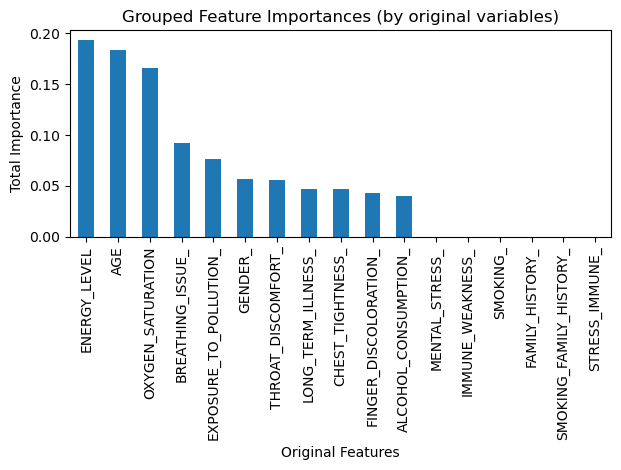

In [331]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Extracting the feature importances from  Random Forest model
importances = rf_pipeline.named_steps['classifier'].feature_importances_

#Retrieving the feature names after preprocessing 
preprocessed_columns = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

grouped_importances = {}

for col, importance in zip(preprocessed_columns, importances):
    base = re.match(r"([a-zA-Z_]+)", col)      
    if base:
        base = base.group(1)  
        grouped_importances[base] = grouped_importances.get(base, 0) + importance


grouped_importance_df = pd.Series(grouped_importances).sort_values(ascending=False)
grouped_importance_df.index = [re.sub(r"^(cat__|float64_|int64_|num__)", "", col) for col in grouped_importance_df.index]

grouped_importance_df.plot.bar()
plt.title("Grouped Feature Importances (by original variables)")
plt.ylabel("Total Importance")
plt.xlabel("Original Features")
plt.tight_layout()
plt.show()

Optimal number of features: 16
Ranking of features: [ 1  1  1  1  1  7  1  3  5  1  1  1  2  6  1  1  1  4  1  1  1  1  8  9
 10]
 Selected Original Features (after grouping dummies):
• AGE
• ALCOHOL
• BREATHING
• FAMILY
• FINGER
• GENDER
• LONG
• MENTAL
• SMOKING
• STRESS
• THROAT


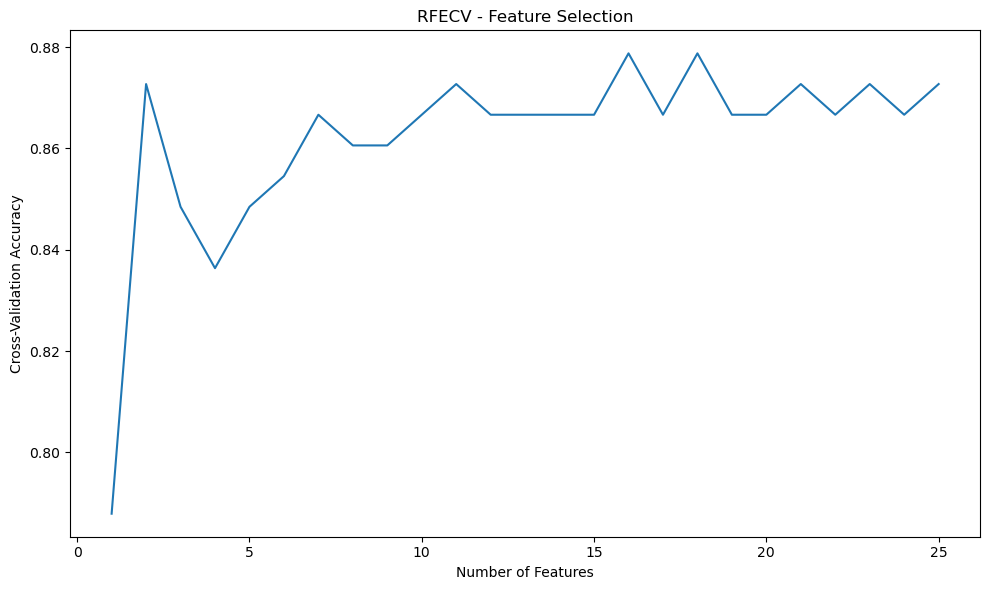

In [332]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rf_classifier = RandomForestClassifier(random_state=42)

rfecv = RFECV(estimator=rf_classifier, 
              step=1,  
              cv=StratifiedKFold(5),  
              scoring='accuracy',  
              n_jobs=-1)  

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('feature_selection', rfecv),  
    ('classifier', rf_classifier)  
])

rf_pipeline.fit(X_cluster3, y_cluster3)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Ranking of features: {rfecv.ranking_}")

import matplotlib.pyplot as plt

all_feature_names = x.columns.tolist()
selected_features_full = [name for name, selected in zip(all_feature_names, rfecv.support_) if selected]

selected_base_features = set()
for feat in selected_features_full:
    match = re.match(r'^([a-zA-Z0-9]+)', feat)
    if match:
        selected_base_features.add(match.group(1))

print(" Selected Original Features (after grouping dummies):")
for feat in sorted(selected_base_features):
    print(f"• {feat}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'])
plt.title('RFECV - Feature Selection')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.tight_layout()
plt.show()


In [ ]:
#model suggested by RFE doesn't perform well for test set since we decided to look at he feature importance plot select the features that improves both training accuracy and test accuracy

In [333]:
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_notscaled)
y_test_encoded = label_encoder.transform(y_test_notscaled)

numeric_features = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]
categorical_features = [col for col in X_train.columns if col not in numeric_features + ['Cluster']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

xgboost_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

for cluster_id in sorted(X_train['Cluster'].unique()):
    print(f"\n=== Cluster {cluster_id} ===")

    train_mask = X_train['Cluster'] == cluster_id
    X_cluster = X_train[train_mask].drop(columns=["Cluster"])
    y_cluster = y_train_encoded[train_mask]

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgboost_classifier)
    ])

    pipeline.fit(X_cluster, y_cluster)

    y_pred_train = pipeline.predict(X_cluster)
    print(f"Training Accuracy: {accuracy_score(y_cluster, y_pred_train):.2f}")
    print(classification_report(y_cluster, y_pred_train, zero_division=1))

    test_mask = X_test['Cluster'] == cluster_id
    if test_mask.sum() > 0:
        X_test_cluster = X_test[test_mask].drop(columns=["Cluster"])
        y_test_cluster = y_test_encoded[test_mask]

        y_pred_test = pipeline.predict(X_test_cluster)
        print(f"Test Accuracy: {accuracy_score(y_test_cluster, y_pred_test):.2f}")
        print(classification_report(y_test_cluster, y_pred_test, zero_division=1))
    else:
        print("No test samples in this cluster.")


=== Cluster 0 ===


C:\Users\Asus\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:52:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1819
           1       0.99      1.00      1.00       701

    accuracy                           1.00      2520
   macro avg       1.00      1.00      1.00      2520
weighted avg       1.00      1.00      1.00      2520

Test Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       416
           1       0.87      0.87      0.87       195

    accuracy                           0.92       611
   macro avg       0.91      0.91      0.91       611
weighted avg       0.92      0.92      0.92       611


=== Cluster 1 ===


C:\Users\Asus\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:52:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       326
           1       1.00      1.00      1.00       342

    accuracy                           1.00       668
   macro avg       1.00      1.00      1.00       668
weighted avg       1.00      1.00      1.00       668

Test Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.90      0.60      0.72        63
           1       0.81      0.96      0.88       108

    accuracy                           0.83       171
   macro avg       0.86      0.78      0.80       171
weighted avg       0.84      0.83      0.82       171


=== Cluster 2 ===


C:\Users\Asus\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:52:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       224
           1       1.00      1.00      1.00       423

    accuracy                           1.00       647
   macro avg       1.00      1.00      1.00       647
weighted avg       1.00      1.00      1.00       647

Test Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.82      0.42      0.56        88
           1       0.60      0.90      0.72        83

    accuracy                           0.65       171
   macro avg       0.71      0.66      0.64       171
weighted avg       0.71      0.65      0.63       171


=== Cluster 3 ===


C:\Users\Asus\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:52:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       142

    accuracy                           1.00       165
   macro avg       1.00      1.00      1.00       165
weighted avg       1.00      1.00      1.00       165

Test Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.93      0.95      0.94        43

    accuracy                           0.89        47
   macro avg       0.63      0.60      0.61        47
weighted avg       0.88      0.89      0.89        47

